In [1]:
from mp_api.client import MPRester
import pandas as pd

from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv("MAPI_API_KEY")

if API_KEY is None:
    raise ValueError("API key not found. Check your .env file.")

with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(
        nelements=(1, 4),
        fields=[
            "material_id",
            "formula_pretty",
            "band_gap",
            "density",
            "is_metal",
            "formation_energy_per_atom",
            "energy_above_hull"
    ],
        num_chunks=40,
        chunk_size=500
    )

df = pd.DataFrame([doc.dict() for doc in docs])

print(df.shape)
df.head(10)

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\mp_api\client\routes\materials\summary.py:278: MPRestWarning: You have specified fields used by `_search` that can be understood by `search`
   nelements
To ensure long term support, please use their `search` equivalents:
   num_elements
Please see the documentation:
    `search`: https://materialsproject.github.io/api/_autosummary/mp_api.client.routes.materials.summary.SummaryRester.html#mp_api.client.routes.materials.summary.SummaryRester.search
   `_search`: https://api.materialsproject.org/redoc#tag/Materials-Summary/operation/search_materials_summary__get
  warnings.warn(
Retrieving SummaryDoc documents: 100%|██████████| 20000/20000

(20000, 8)


,formula_pretty,density,material_id,formation_energy_per_atom,energy_above_hull,band_gap,is_metal,fields_not_requested
0,Ac,8.157868,mp-ovi,0.021639,0.021639,0.0,True,"[builder_meta, nsites, elements, nelements, co..."
1,Ac,8.313274,mp-cpicf,0.015586,0.015586,0.0,True,"[builder_meta, nsites, elements, nelements, co..."
2,Ac,8.144760,mp-cpicr,0.011822,0.011822,0.0,True,"[builder_meta, nsites, elements, nelements, co..."
3,Ac,8.170182,mp-bxcek,0.000000,0.000000,0.0,True,"[builder_meta, nsites, elements, nelements, co..."
4,Ac2AgIr,11.367264,mp-bxatg,-0.413285,0.087118,0.0,True,"[builder_meta, nsites, elements, nelements, co..."
5,Ac2AgPb,9.490476,mp-cpicy,-0.480278,0.000000,0.0,True,"[builder_meta, nsites, elements, nelements, co..."
6,Ac2Br2O,3.512584,mp-cqryn,-1.460073,1.242844,0.0,True,"[builder_meta, nsites, elements, nelements, co..."
7,Ac2CdGa,8.243210,mp-cpicq,-0.402831,0.027137,0.0,True,"[builder_meta, nsites, elements, nelements, co..."
8,Ac2CdGe,8.449542,mp-cpicl,-0.464809,0.059054,0.0,True,"[builder_meta, nsites, elements, nelements, co..."
9,Ac2CdHg,9.570977,mp-cpidi,-0.433682,0.000000,0.0,True,"[builder_meta, nsites, elements, nelements, co..."


In [19]:
df.to_csv("../data/raw/materials_data.csv", index=False)

<Axes: >

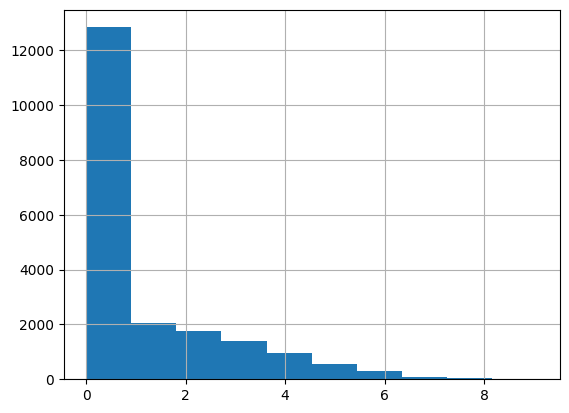

In [20]:
df["band_gap"].hist()